# Sistema de Recomendação de Filmes
### Filtragem Colaborativa com KNN + Análise Exploratória

**Fluxo do notebook:**
1. Importações
2. Carregamento dos dados
3. Tratamento e preparação dos dados
4. Análise Exploratória (EDA)
5. Filtragem Colaborativa (Item-Item via KNN)

---
## 1. Importações

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from wordcloud import WordCloud

---
## 2. Carregamento dos Dados

In [2]:
df_meta    = pd.read_csv('../Data/movies_metadata.csv', low_memory=False)
df_ratings = pd.read_csv('../Data/ratings_small.csv')
df_keywords = pd.read_csv('../Data/keywords.csv')

print(f'Metadados:  {df_meta.shape}')
print(f'Avaliações: {df_ratings.shape}')
print(f'Keywords:   {df_keywords.shape}')

Metadados:  (45466, 24)
Avaliações: (100004, 4)
Keywords:   (46419, 2)


---
## 3. Tratamento e Preparação dos Dados

Etapas:
- Remover IDs não numéricos em `movies_metadata`
- Fazer parse das colunas JSON (`genres`, `keywords`)
- Merge dos datasets
- Converter e extrair o ano de lançamento
- Filtrar esparsidade na matriz de avaliações

In [3]:
df_meta = df_meta[df_meta['id'].apply(lambda x: str(x).isnumeric())].copy()
df_meta['id'] = df_meta['id'].astype(int)
df_keywords['id'] = df_keywords['id'].astype(int)

print(f'Metadados após remoção de IDs inválidos: {df_meta.shape}')

Metadados após remoção de IDs inválidos: (45463, 24)


In [4]:
def parse_json(column_str):
    try:
        return [item['name'] for item in ast.literal_eval(column_str)]
    except:
        return []

df_meta['genres']       = df_meta['genres'].apply(parse_json)
df_keywords['keywords'] = df_keywords['keywords'].apply(parse_json)

print('Exemplo de gêneros parseados:')
print(df_meta[['id', 'title', 'genres']].head(3))

Exemplo de gêneros parseados:
      id             title                        genres
0    862         Toy Story   [Animation, Comedy, Family]
1   8844           Jumanji  [Adventure, Fantasy, Family]
2  15602  Grumpier Old Men             [Romance, Comedy]


In [5]:
df_meta = df_meta.merge(df_keywords, on='id', how='left')

df_meta['release_date'] = pd.to_datetime(df_meta['release_date'], errors='coerce')
df_meta['year'] = df_meta['release_date'].dt.year.fillna(0).astype(int)

df_meta = df_meta[['id', 'title', 'genres', 'keywords', 'year', 'vote_average', 'vote_count']]

print(f'df_meta final: {df_meta.shape}')
df_meta.head(3)

df_meta final: (46483, 7)


,id,title,genres,keywords,year,vote_average,vote_count
0,862,Toy Story,"[Animation, Comedy, Family]","[jealousy, toy, boy, friendship, friends, riva...",1995,7.7,5415.0
1,8844,Jumanji,"[Adventure, Fantasy, Family]","[board game, disappearance, based on children'...",1995,6.9,2413.0
2,15602,Grumpier Old Men,"[Romance, Comedy]","[fishing, best friend, duringcreditsstinger, o...",1995,6.5,92.0


In [6]:
print(f'Avaliações antes do filtro: {df_ratings.shape[0]:,}')

movie_counts = df_ratings.groupby('movieId')['rating'].count()
filmes_validos = movie_counts[movie_counts >= 10].index
df_ratings = df_ratings[df_ratings['movieId'].isin(filmes_validos)]

user_counts = df_ratings.groupby('userId')['rating'].count()
usuarios_validos = user_counts[user_counts >= 20].index
df_ratings = df_ratings[df_ratings['userId'].isin(usuarios_validos)]

print(f'Avaliações após o filtro:  {df_ratings.shape[0]:,}')
print(f'Filmes únicos:  {df_ratings["movieId"].nunique()}')
print(f'Usuários únicos: {df_ratings["userId"].nunique()}')

Avaliações antes do filtro: 100,004
Avaliações após o filtro:  81,484
Filmes únicos:  2245
Usuários únicos: 646


---
## 4. Análise Exploratória dos Dados (EDA)

C:\Users\Xno\AppData\Local\Temp\ipykernel_7648\3909012243.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


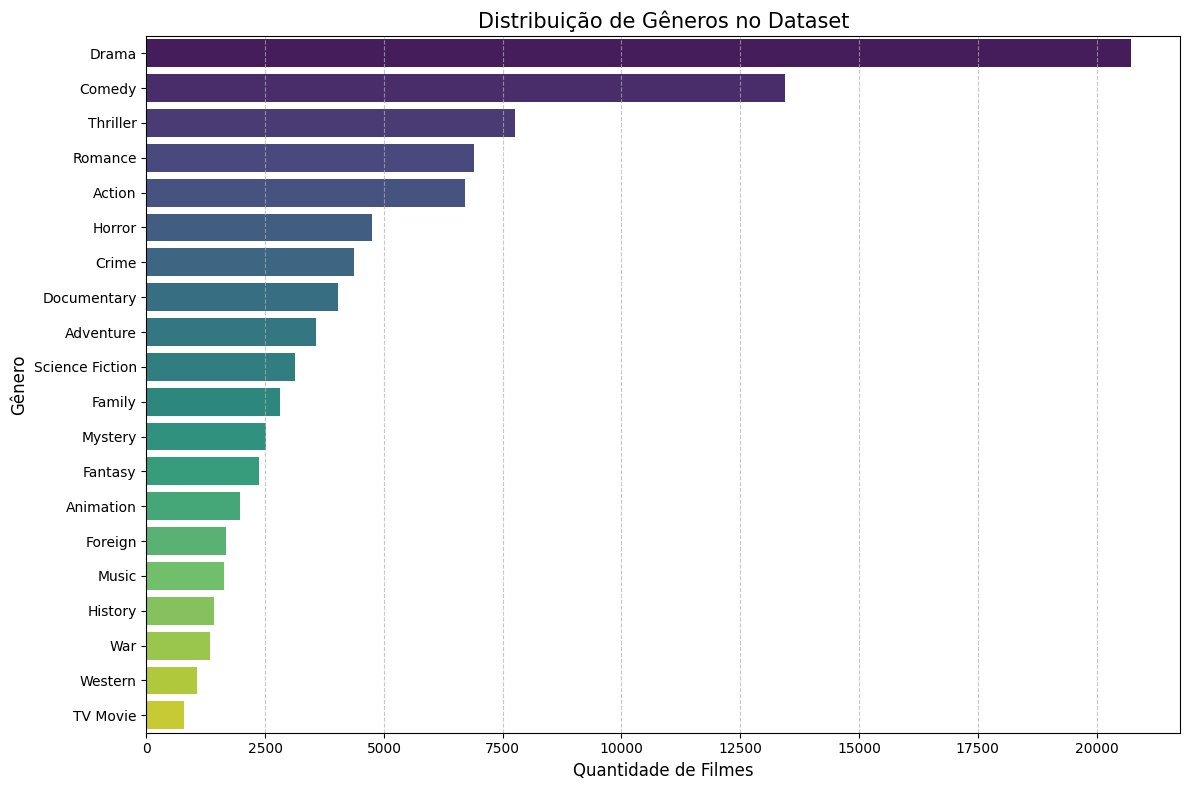

In [7]:
generos_separados = df_meta.explode('genres').reset_index(drop=True)
generos_separados = generos_separados.dropna(subset=['genres'])
generos_separados = generos_separados[generos_separados['genres'] != '']

plt.figure(figsize=(12, 8))
sns.countplot(
    y='genres',
    data=generos_separados,
    order=generos_separados['genres'].value_counts().index,
    palette='viridis'
)
plt.title('Distribuição de Gêneros no Dataset', fontsize=15)
plt.xlabel('Quantidade de Filmes', fontsize=12)
plt.ylabel('Gênero', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\Xno\AppData\Local\Temp\ipykernel_7648\2856714518.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='vote_average', y='title', data=top_voted, palette='magma')


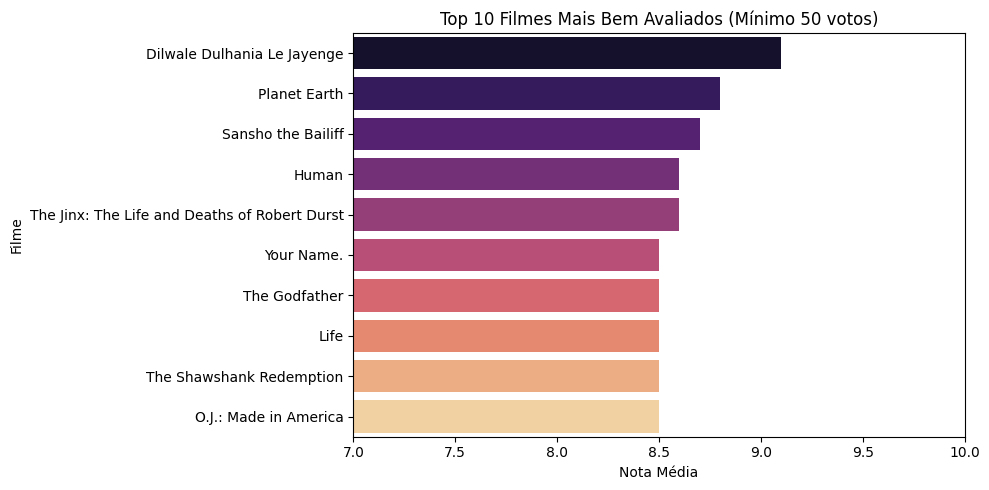

In [8]:
top_voted = (
    df_meta[df_meta['vote_count'] > 50]
    .sort_values('vote_average', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(x='vote_average', y='title', data=top_voted, palette='magma')
plt.title('Top 10 Filmes Mais Bem Avaliados (Mínimo 50 votos)')
plt.xlabel('Nota Média')
plt.ylabel('Filme')
plt.xlim(7, 10)
plt.tight_layout()
plt.show()

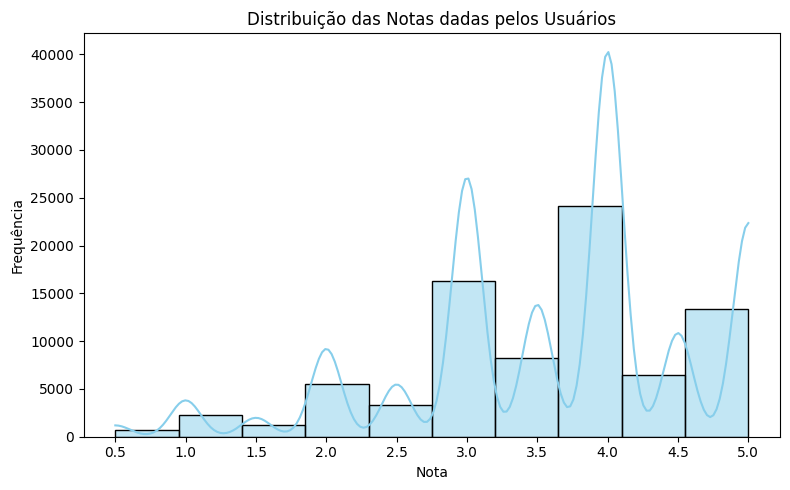

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df_ratings['rating'], bins=10, kde=True, color='skyblue')
plt.title('Distribuição das Notas dadas pelos Usuários')
plt.xlabel('Nota')
plt.ylabel('Frequência')
plt.xticks([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
plt.tight_layout()
plt.show()

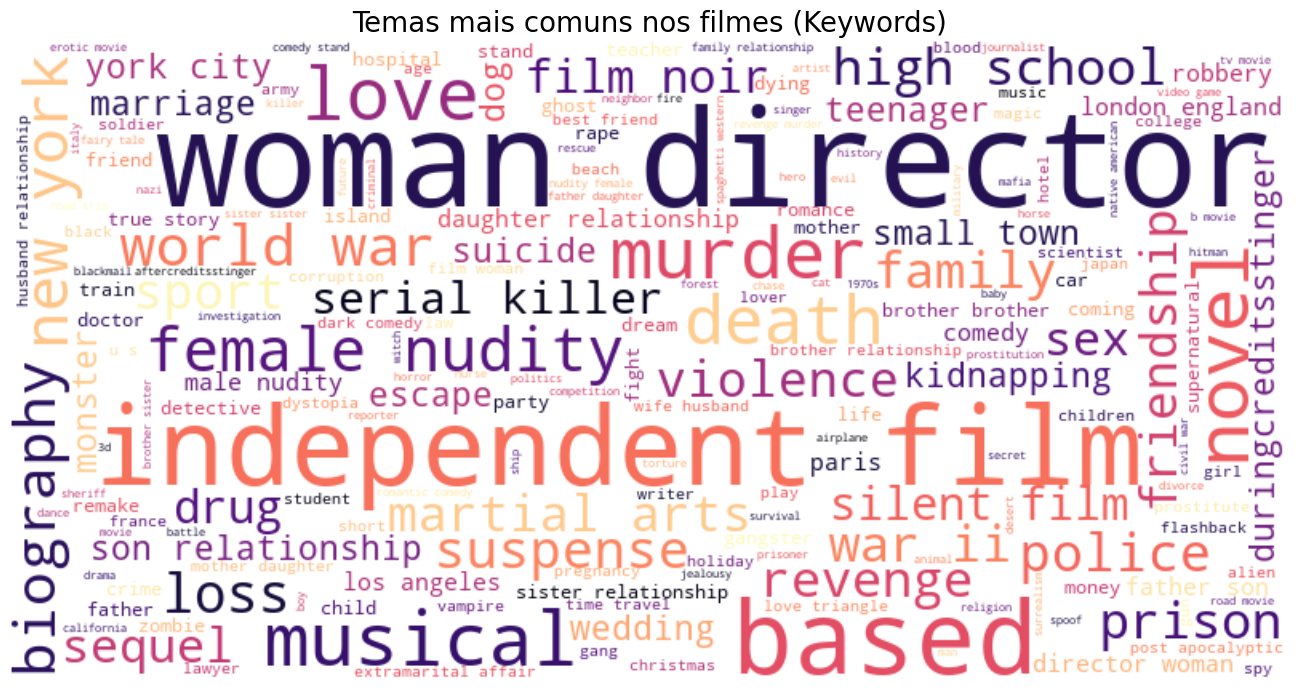

In [10]:
todas_keywords = df_meta.explode('keywords')['keywords'].dropna().tolist()
texto_keywords = " ".join(todas_keywords)

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='magma'
).generate(texto_keywords)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Temas mais comuns nos filmes (Keywords)', fontsize=20)
plt.tight_layout()
plt.show()

---
## 5. Filtragem Colaborativa (Item-Item via KNN)

A ideia da **filtragem colaborativa item-item** é: *filmes que foram avaliados de forma parecida pelos mesmos usuários tendem a ser similares*.

Passos:
1. Construir a matriz **Filme × Usuário** com as notas
2. Converter para formato esparso (economia de memória)
3. Treinar o modelo KNN com similaridade de cosseno
4. Função de recomendação por nome de filme

In [16]:
user_item_matrix = df_ratings.pivot(
    index='movieId',
    columns='userId',
    values='rating'
).fillna(0)

print(f'Dimensões da matriz Filme × Usuário: {user_item_matrix.shape}')
print(f'Esparsidade: {(user_item_matrix == 0).sum().sum() / user_item_matrix.size:.1%} de zeros')

Dimensões da matriz Filme × Usuário: (2245, 646)
Esparsidade: 94.4% de zeros


In [17]:
movie_matrix_sparse = csr_matrix(user_item_matrix.values)
print(f'Matriz esparsa criada: {movie_matrix_sparse.shape}')

Matriz esparsa criada: (2245, 646)


In [18]:
model_knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=20)
model_knn.fit(movie_matrix_sparse)

print('Modelo KNN treinado com sucesso!')

Modelo KNN treinado com sucesso!


In [19]:
def recomendar_filmes(nome_do_filme=None, movie_id=None, n_recomendacoes=5):
    """
    Recomenda filmes similares com base em filtragem colaborativa item-item (KNN).

    Parâmetros:
    -----------
    nome_do_filme  : str  — busca pelo título (parcial, ignora maiúsculas)
    movie_id       : int  — movieId diretamente da matriz (MovieLens ID)
    n_recomendacoes: int  — quantidade de filmes recomendados
    """
    if movie_id is not None:
        if movie_id not in user_item_matrix.index:
            return f'movieId {movie_id} não encontrado na matriz.'
        idx_na_matriz = user_item_matrix.index.get_loc(movie_id)
        titulo_exibido = f'movieId {movie_id}'

    elif nome_do_filme is not None:
        resultado = df_meta[df_meta['title'].str.contains(nome_do_filme, case=False, na=False)]
        if resultado.empty:
            return f'Nenhum filme encontrado com o nome "{nome_do_filme}".'

        encontrado = None
        for _, row in resultado.iterrows():
            if row['id'] in user_item_matrix.index:
                encontrado = row
                break

        if encontrado is None:
            disponiveis = resultado['id'].tolist()
            return (
                f'Filme "{nome_do_filme}" encontrado no catálogo, mas sem avaliações suficientes na matriz.\n'
                f'Dica: os IDs TMDB encontrados foram {disponiveis}.\n'
                f'Tente chamar a função com movie_id=<um dos movieIds da matriz>.'
            )

        idx_na_matriz = user_item_matrix.index.get_loc(encontrado['id'])
        titulo_exibido = encontrado['title']

    else:
        return 'Informe nome_do_filme ou movie_id.'

    distancias, indices = model_knn.kneighbors(
        user_item_matrix.iloc[idx_na_matriz, :].values.reshape(1, -1),
        n_neighbors=n_recomendacoes + 1
    )

    print(f'Filmes recomendados para quem gostou de: {titulo_exibido}\n')
    print(f'{"Pos":<5} {"Título":<45} {"Similaridade":>12}')
    print('-' * 65)

    for i in range(1, len(distancias.flatten())):
        id_recomendado = user_item_matrix.index[indices.flatten()[i]]
        similaridade   = 1 - distancias.flatten()[i]  
        titulo_rec = df_meta[df_meta['id'] == id_recomendado]['title']
        titulo_rec = titulo_rec.values[0] if not titulo_rec.empty else f'ID {id_recomendado}'

        print(f'{i:<5} {titulo_rec:<45} {similaridade:>11.3f}')

In [20]:
recomendar_filmes(nome_do_filme='Toy Story')

print('\n' + '='*65 + '\n')

recomendar_filmes(movie_id=1)



Filmes recomendados para quem gostou de: movieId 1

Pos   Título                                        Similaridade
-----------------------------------------------------------------
1     The Searchers                                       0.598
2     The 39 Steps                                        0.578
3     The Passion of Joan of Arc                          0.564
4     ID 356                                              0.563
5     Bridge to Terabithia                                0.549


---

O sistema de recomendação implementado utiliza **filtragem colaborativa item-item** com **KNN (K-Nearest Neighbors)** e **similaridade de cosseno**. A lógica central é:

- Filmes avaliados de forma parecida pelos mesmos usuários são considerados similares
- A similaridade de cosseno mede o ângulo entre os vetores de avaliação — quanto menor o ângulo, mais similares os filmes
- O uso de matriz esparsa (`csr_matrix`) garante eficiência de memória mesmo com alta esparsidade

